Using device: cuda

=== Fold 1 ===
RMSE: 0.0446
MAE: 0.0346
R2: -0.1308
Directional Accuracy: 46.92%


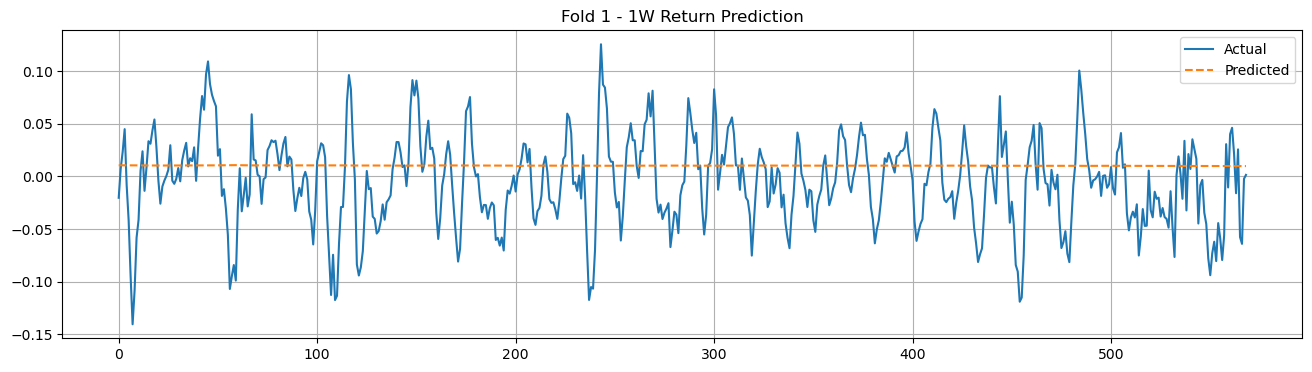


=== Fold 2 ===
RMSE: 0.0401
MAE: 0.0306
R2: -0.0981
Directional Accuracy: 49.38%


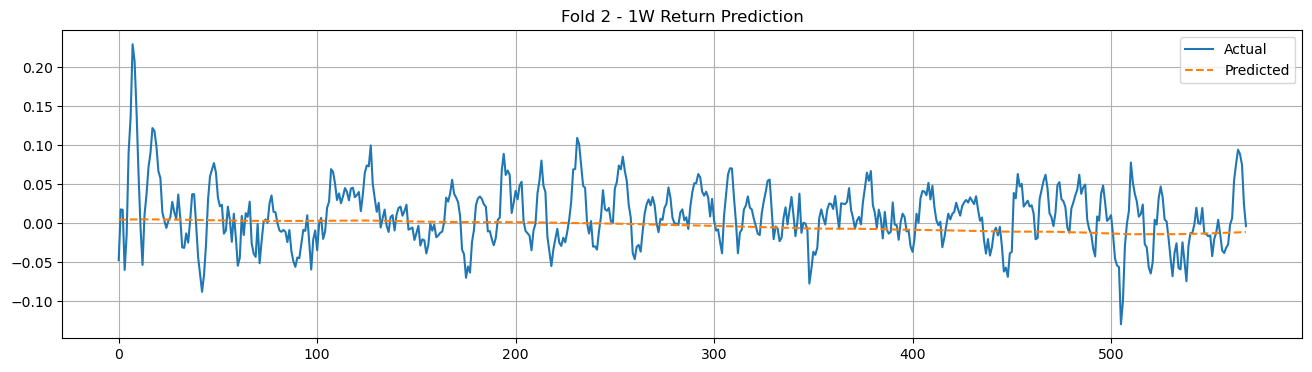


=== Fold 3 ===
RMSE: 0.0655
MAE: 0.0438
R2: -0.0185
Directional Accuracy: 55.71%


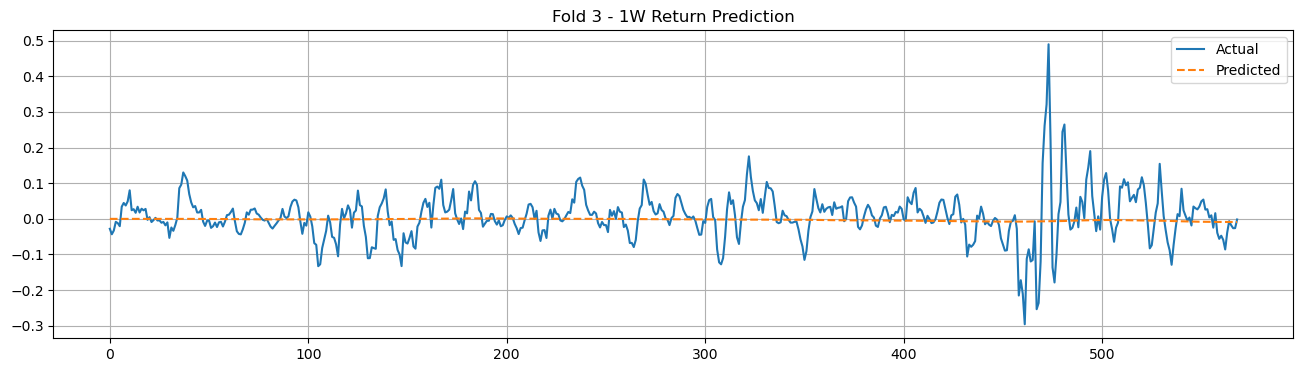


=== Fold 4 ===
RMSE: 0.0510
MAE: 0.0390
R2: -0.0024
Directional Accuracy: 51.85%


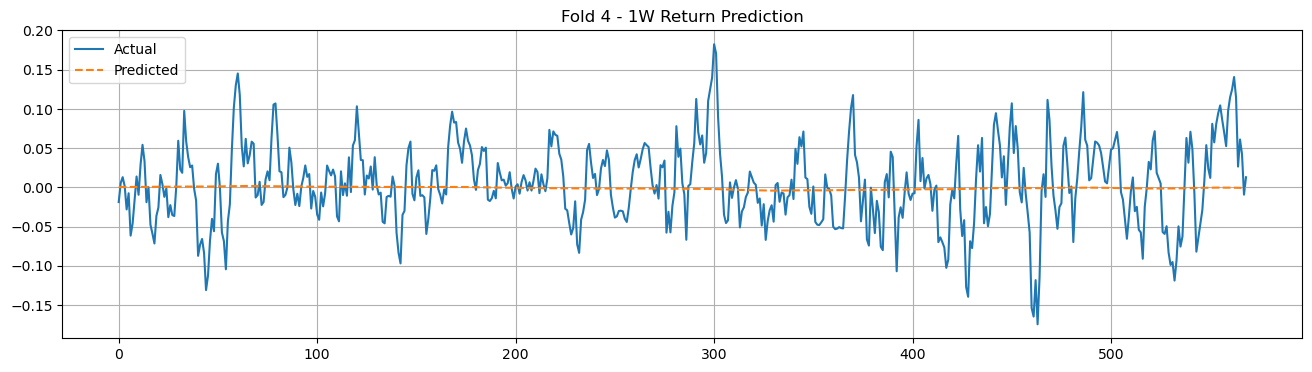


=== Fold 5 ===
RMSE: 0.2788
MAE: 0.2160
R2: -38.6703
Directional Accuracy: 37.08%


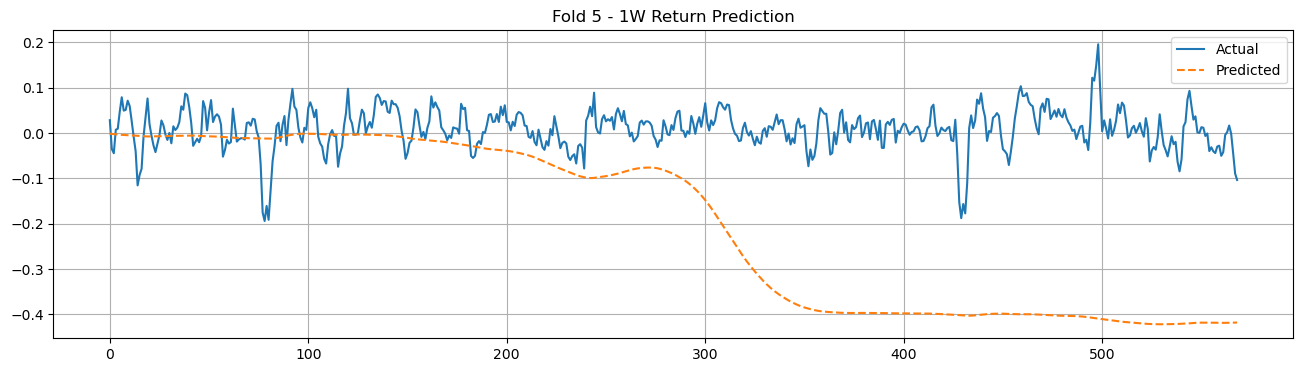

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, accuracy_score
import matplotlib.pyplot as plt

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Load data
df = pd.read_csv("APO.csv")
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values(by='Date')

# Technical Indicators
df['SMA_10'] = df['Close_Prices'].rolling(window=10).mean()
df['EMA_10'] = df['Close_Prices'].ewm(span=10, adjust=False).mean()
df['RSI'] = 100 - (100 / (1 + df['Close_Prices'].pct_change().rolling(14).mean() /
                          df['Close_Prices'].pct_change().rolling(14).std()))
df['MACD'] = df['Close_Prices'].ewm(span=12).mean() - df['Close_Prices'].ewm(span=26).mean()
df['Bollinger_High'] = df['Close_Prices'].rolling(20).mean() + 2 * df['Close_Prices'].rolling(20).std()
df['Bollinger_Low'] = df['Close_Prices'].rolling(20).mean() - 2 * df['Close_Prices'].rolling(20).std()

# Target: 5-day future return and classification
df['Target_Change'] = df['Close_Prices'].shift(-5) / df['Close_Prices'] - 1
df['Target_Class'] = (df['Target_Change'] > 0).astype(int)
df.dropna(inplace=True)

# Features & targets
features = ['Close_Prices', 'Open_Prices', 'High_Prices', 'Low_Prices', 'Volume',
            'SMA_10', 'EMA_10', 'RSI', 'MACD', 'Bollinger_High', 'Bollinger_Low']
X = df[features]
y_reg = df['Target_Change'].values.reshape(-1, 1)
y_cls = df['Target_Class'].values.reshape(-1, 1)

# Normalize features
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# Create sequences
SEQ_LENGTH = 60
def create_sequences(data, labels_reg, labels_cls, seq_len):
    X_seq, y_seq_reg, y_seq_cls = [], [], []
    for i in range(len(data) - seq_len):
        X_seq.append(data[i:i+seq_len])
        y_seq_reg.append(labels_reg[i+seq_len])
        y_seq_cls.append(labels_cls[i+seq_len])
    return np.array(X_seq), np.array(y_seq_reg), np.array(y_seq_cls)

X_seq, y_seq_reg, y_seq_cls = create_sequences(X_scaled, y_reg, y_cls, SEQ_LENGTH)

# LSTM Model
class LSTMRegClass(nn.Module):
    def __init__(self, input_size=11, hidden_size=512, num_layers=2):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True, dropout=0.3)
        self.reg_head = nn.Linear(hidden_size, 1)
        self.cls_head = nn.Linear(hidden_size, 1)

    def forward(self, x):
        out, _ = self.lstm(x)
        last = out[:, -1, :]
        return self.reg_head(last), torch.sigmoid(self.cls_head(last))

# TimeSeriesSplit Cross-validation
tscv = TimeSeriesSplit(n_splits=5)
fold = 1

for train_idx, test_idx in tscv.split(X_seq):
    print(f"\n=== Fold {fold} ===")
    X_train, y_reg_train, y_cls_train = X_seq[train_idx], y_seq_reg[train_idx], y_seq_cls[train_idx]
    X_test, y_reg_test, y_cls_test = X_seq[test_idx], y_seq_reg[test_idx], y_seq_cls[test_idx]

    # Tensors
    X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
    y_reg_train = torch.tensor(y_reg_train, dtype=torch.float32).to(device)
    y_cls_train = torch.tensor(y_cls_train, dtype=torch.float32).to(device)

    X_test = torch.tensor(X_test, dtype=torch.float32).to(device)
    y_reg_test = torch.tensor(y_reg_test, dtype=torch.float32).to(device)
    y_cls_test = torch.tensor(y_cls_test, dtype=torch.float32).to(device)

    # Model setup
    model = LSTMRegClass().to(device)
    criterion_reg = nn.MSELoss()
    criterion_cls = nn.BCELoss()
    optimizer = optim.Adam(model.parameters(), lr=0.0001)

    # Training loop
    EPOCHS = 100
    for epoch in range(EPOCHS):
        model.train()
        optimizer.zero_grad()
        pred_reg, pred_cls = model(X_train)
        loss = criterion_reg(pred_reg, y_reg_train) + criterion_cls(pred_cls, y_cls_train)
        loss.backward()
        optimizer.step()

    # Evaluation
    model.eval()
    with torch.no_grad():
        pred_reg, pred_cls = model(X_test)
        pred_reg = pred_reg.cpu().numpy()
        pred_cls = (pred_cls.cpu().numpy() > 0.5).astype(int)
        y_reg_true = y_reg_test.cpu().numpy()
        y_cls_true = y_cls_test.cpu().numpy()

    # Metrics
    print(f"RMSE: {np.sqrt(mean_squared_error(y_reg_true, pred_reg)):.4f}")
    print(f"MAE: {mean_absolute_error(y_reg_true, pred_reg):.4f}")
    print(f"R2: {r2_score(y_reg_true, pred_reg):.4f}")
    print(f"Directional Accuracy: {accuracy_score(y_cls_true, pred_cls) * 100:.2f}%")

    # Optional: Plot results for this fold
    plt.figure(figsize=(16, 4))
    plt.plot(y_reg_true, label='Actual')
    plt.plot(pred_reg, label='Predicted', linestyle='dashed')
    plt.title(f'Fold {fold} - 1W Return Prediction')
    plt.legend()
    plt.grid(True)
    plt.show()

    fold += 1
